In [1]:
import torch
import pandas as pd
import sys
import os

In [2]:
group_id_str = 'fig3facin1p2_refac'
test_image_dir = '/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_output/Fascin_1p2_uM_fig3/processed_MT/GUV-MT_obj_png_selected_std15'

obj_df = pd.read_csv('/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_output/Fascin_1p2_uM_fig3/processed_MT/facin_guv_mt_cell_df_circle_selected_std15.csv')


group_con = 'tau'
group_title= 'Fascin with Tau'

In [3]:
# Get the directory of the script
script_dir = os.getcwd()
parent_dir = os.path.dirname(script_dir)
sys.path.append(parent_dir)

from utils.plotting_functions import plot_training_images_by_label,stack_percentile, df_add_group_guv_size
from utils.mt_classifier import classify_and_save_images


In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load CSV
data_csv = "/mnt/d/lding/CLS/mousumiLiuDinner/selected_for_annotation_mt_strcture_20250310_MA.csv"
df = pd.read_csv(data_csv)
df = df.dropna(subset=["filename", "label"])
df["label"] = df["label"].astype(str)
best_model_path = "/mnt/d/lding/CLS/mousumiLiuDinner/figures202506182201/cleanning_version_cellpose_best_modelfigures202506182201.pth"  # Path to the best model


In [5]:
output_dir = "/mnt/d/lding/CLS/mousumiLiuDinner/revision_"+group_id_str+"_classified_images_0618cellpose"  # Output directory to save classified images
result_csv = output_dir + "/revision_"+group_id_str+"_classification_results_0618cellpose.csv"  # CSV file to save predictions
result_category_csv = output_dir + "/revision_"+group_id_str+"_classification_results_category_0618cellpose.csv"  # CSV file to save predictions
os.makedirs(output_dir, exist_ok=True)


In [6]:
label_to_index = {label: idx for idx, label in enumerate(sorted(df["label"].unique()))}
results_df = classify_and_save_images("efficientnet", test_image_dir, best_model_path, output_dir, label_to_index,result_csv,device)


Results saved to: /mnt/d/lding/CLS/mousumiLiuDinner/revision_fig3facin1p2_refac_classified_images_0618cellpose/revision_fig3facin1p2_refac_classification_results_0618cellpose.csv
Images saved in respective predicted label folders under: /mnt/d/lding/CLS/mousumiLiuDinner/revision_fig3facin1p2_refac_classified_images_0618cellpose


In [7]:
label_results_df = results_df.rename(columns={"predicted_label": "label"})
plot_training_images_by_label(label_results_df, test_image_dir, output_dir)

['Network' 'Cluster' 'Filaments' 'ZZZ' 'Patch']


In [8]:
df = df_add_group_guv_size(label_results_df, obj_df, test_image_dir)
df.to_csv(result_category_csv, index=False)
print("Saved: "+result_category_csv)

Saved: /mnt/d/lding/CLS/mousumiLiuDinner/revision_fig3facin1p2_refac_classified_images_0618cellpose/revision_fig3facin1p2_refac_classification_results_category_0618cellpose.csv


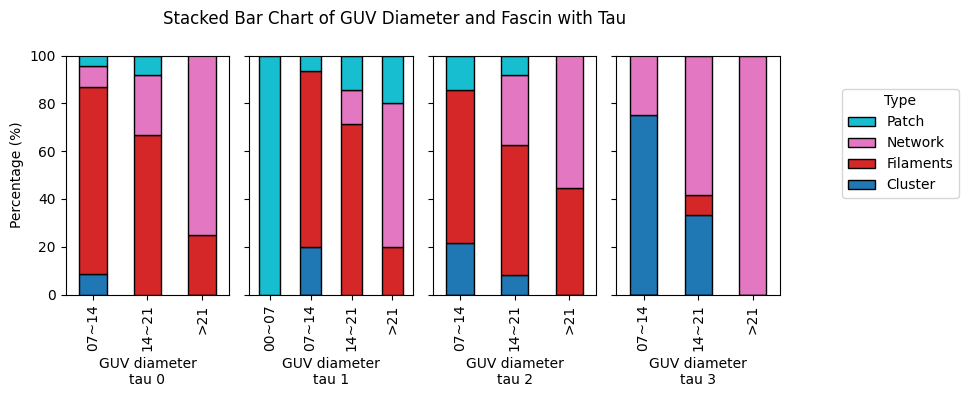

In [9]:
fig = stack_percentile(df, group_con = group_con, group_title= group_title)
fig.savefig(os.path.join(output_dir, 'stackbox.png'), bbox_inches='tight')
